<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


NaN values in compensation before cleaning: 42002
NaN values in compensation after cleaning: 0


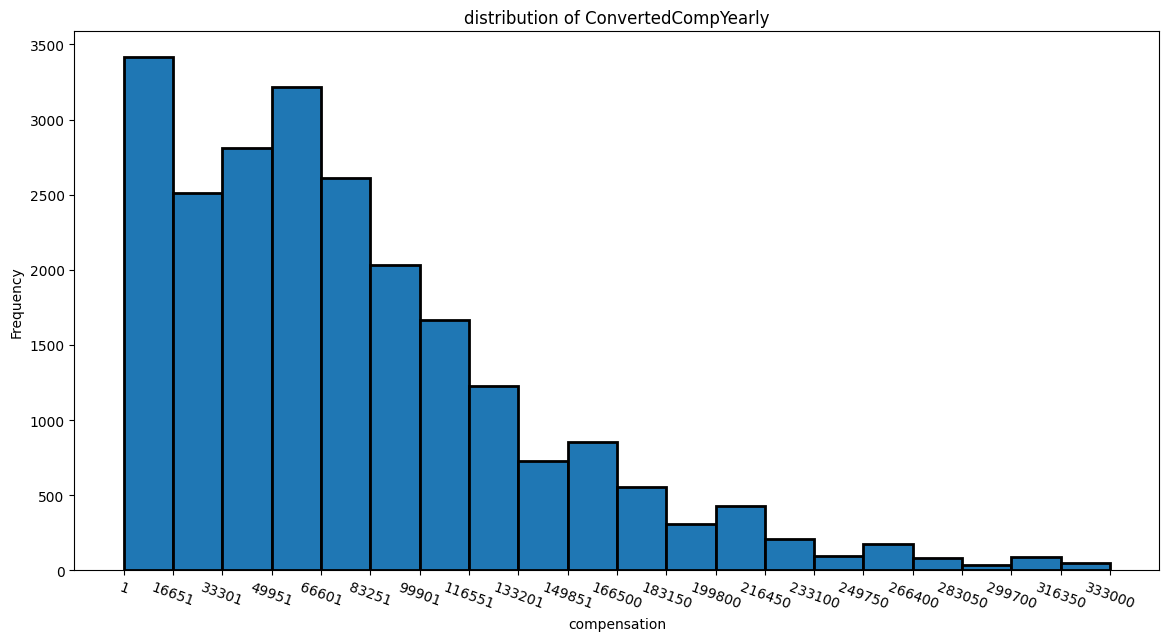

In [3]:
## Write your code here

df_comp=df.copy()

print('NaN values in compensation before cleaning:',df_comp['ConvertedCompYearly'].isnull().sum())
df_comp=df_comp.dropna(subset=['ConvertedCompYearly'], axis=0)                                        # Dropping null values to ensure correct calculations
print('NaN values in compensation after cleaning:',df_comp['ConvertedCompYearly'].isnull().sum())

Q1=np.quantile(df_comp['ConvertedCompYearly'], 0.25)
Q3=np.quantile(df_comp['ConvertedCompYearly'], 0.75)
IQR=Q3-Q1

max_value=Q3+3*IQR                                      # Using the standard 1.5 IQR removed nearly 1,000 responses, so to avoid losing a significant number of valid observations, the threshold was increased to 3 IQR to remove only extreme values
min_value=Q1-1.5*IQR                                    # Compensation data is typically right-skewed; therefore, a wider threshold was applied to the upper tail to avoid removing valid high-income observations.
                                                        # More analysis of this column in notebook Data_wrangling/09_Imput_Missing_Values

df_comp=df_comp[((df_comp['ConvertedCompYearly']<max_value) & 
                 (df_comp['ConvertedCompYearly']>min_value)
                )]

entries_in_bin, bin_range=np.histogram(df_comp['ConvertedCompYearly'],20)

df_comp['ConvertedCompYearly'].plot(kind='hist', figsize=(14,7), xticks=bin_range, linewidth=2, edgecolor='black', bins=20)
plt.xticks(rotation=-20)
plt.xlabel('compensation')
plt.title('distribution of ConvertedCompYearly')
plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [4]:
## Write your code here
full_time_employees=df[df['Employment']=="Employed, full-time"]
print('median_compensation for full time employees:', full_time_employees['ConvertedCompYearly'].median())

median_compensation for full time employees: 69814.0


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



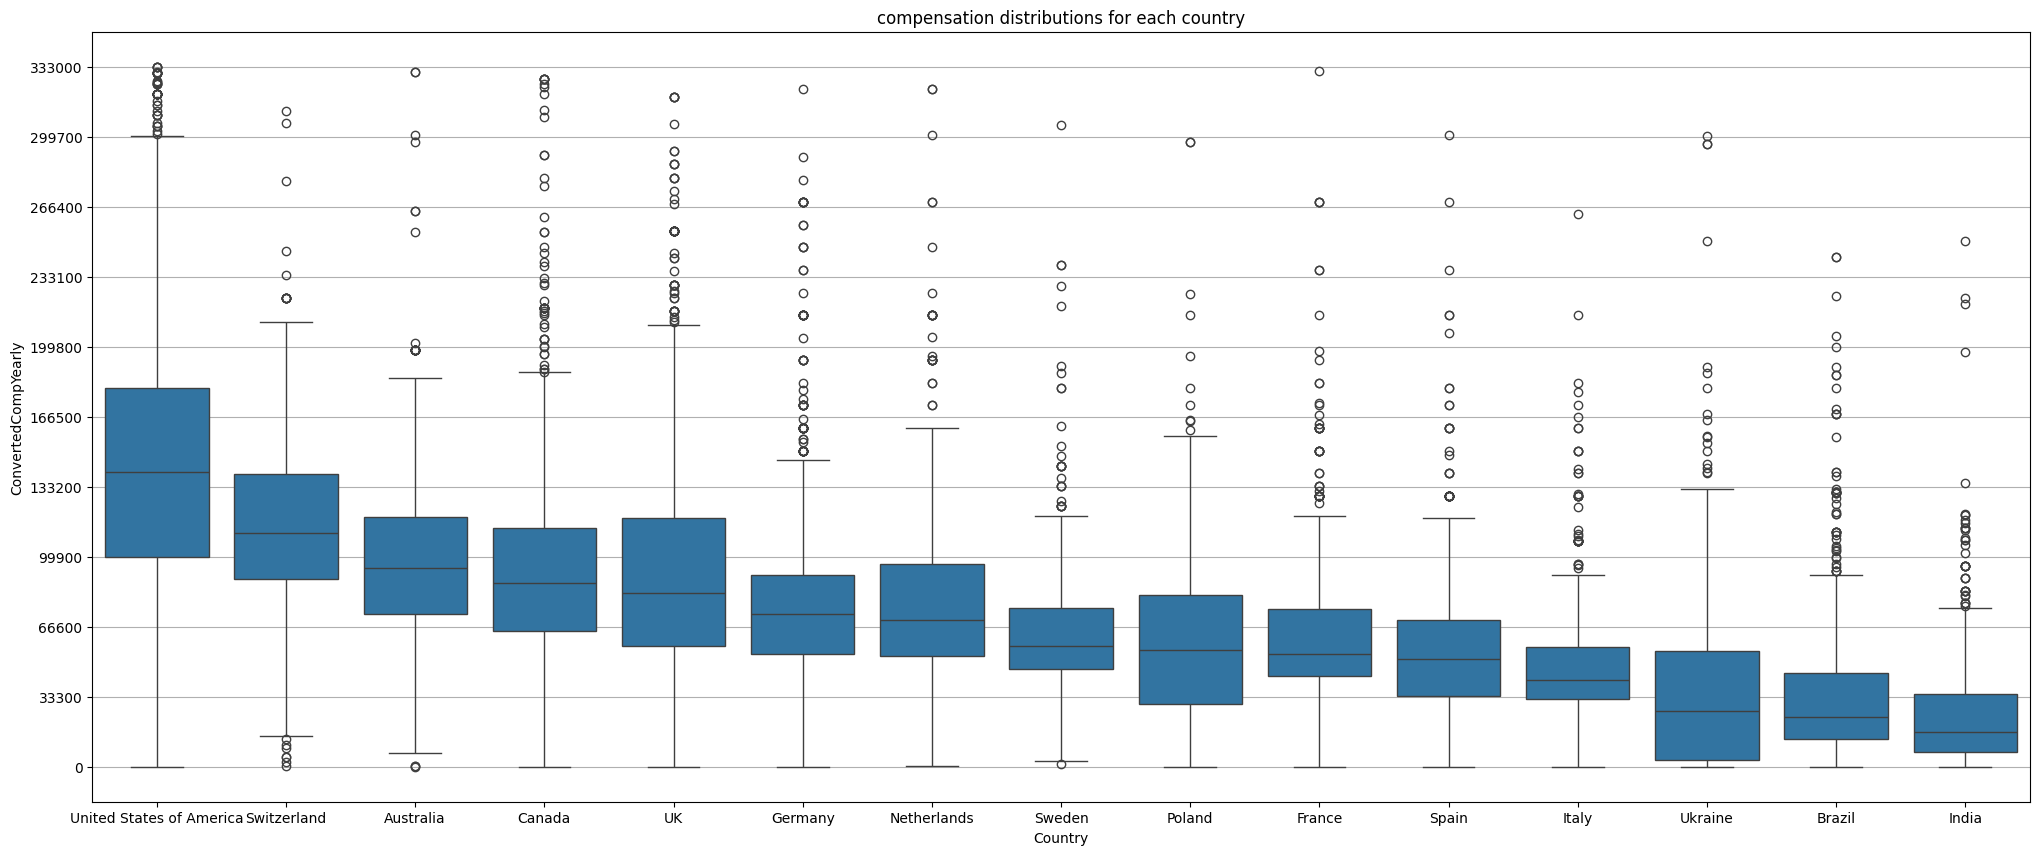

In [5]:
## Write your code here
top15_countries=(
    df_comp.groupby('Country').size().reset_index(name='count')
    .sort_values('count', ascending=False).head(15)
)
                
df_comp_top15=df_comp[df_comp['Country'].isin(top15_countries['Country'])]          # Limit data to top 15 countries for better visualization clarity


df_comp_top15['Country']=df_comp_top15['Country'].replace('United Kingdom of Great Britain and Northern Ireland','UK')

plt.figure(figsize=(25,10))
sns.boxplot(df_comp_top15, x='Country', y='ConvertedCompYearly', order=df_comp_top15.groupby('Country')['ConvertedCompYearly'].median().sort_values(ascending=False).index)
plt.title('compensation distributions for each country')
plt.yticks(np.linspace(0, df_comp_top15['ConvertedCompYearly'].max(), 11))
plt.grid(axis='y')
plt.show()

The highest compensation among respondents is observed in the United States, where over 75% of employees earn more than 100,000 USD annually. Other countries in which at least 25% of top-earning specialists exceed the 100,000 USD threshold include developed English-speaking countries such as the United Kingdom, Canada, and Australia. An exception to this pattern is Switzerland, where more than 50% of developers earn above 100,000 USD per year.

On the opposite side, countries such as Ukraine, India, and Brazil show significantly lower compensation levels, with more than half of respondents earning less than 30,000 USD annually. These differences may reflect economic conditions present in these countries.

In the remaining countries, the vast majority of respondents report annual compensation in the range of 33,000 to 100,000 USD. 

*It is important to note that compensation values are reported in nominal USD and are not adjusted for purchasing power parity (PPP)*.

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [6]:
## Write your code here

df_compensation=df.copy()

print('NaN values in compensation before cleaning:',df_compensation['ConvertedCompYearly'].isnull().sum())
df_compensation=df_compensation.dropna(subset=['ConvertedCompYearly'], axis=0)                                        # Dropping null values to ensure correct calculations
print('NaN values in compensation after cleaning:',df_compensation['ConvertedCompYearly'].isnull().sum())

Q1C=np.quantile(df_compensation['ConvertedCompYearly'], 0.25)
Q3C=np.quantile(df_compensation['ConvertedCompYearly'], 0.75)
IQR_comp=Q3C-Q1C

max_val=Q3C+3*IQR_comp                                      # Using the standard 1.5 IQR removed nearly 1,000 responses, so to avoid losing a significant number of valid observations, the threshold was increased to 3 IQR to remove only extreme values
min_val=Q1C-1.5*IQR_comp                                    # Compensation data is typically right-skewed; therefore, a wider threshold was applied to the upper tail to avoid removing valid high-income observations.
                                                        # More analysis of this column in notebook Data_wrangling/09_Imput_Missing_Values

df_compensation=df_compensation[((df_compensation['ConvertedCompYearly']<max_val) & 
                 (df_compensation['ConvertedCompYearly']>min_val)
                )]

df_compensation['ConvertedCompYearly'].describe()

NaN values in compensation before cleaning: 42002
NaN values in compensation after cleaning: 0


count     23119.000000
mean      76831.016091
std       60002.888870
min           1.000000
25%       32222.000000
50%       64444.000000
75%      107338.500000
max      333000.000000
Name: ConvertedCompYearly, dtype: float64

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


null values in matrix 

 ConvertedCompYearly       0
WorkExp                7179
JobSatPoints_1         7204
dtype: int64


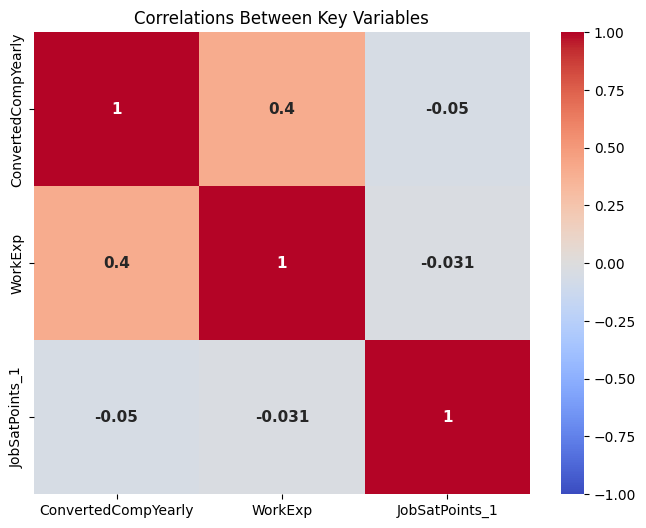

In [7]:
## Write your code here

matrix=df_compensation[['ConvertedCompYearly','WorkExp','JobSatPoints_1']]

print('null values in matrix \n\n', matrix.isnull().sum())

corr_matrix=matrix.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, annot_kws={'fontsize':11, 'fontweight':'bold'}, vmin=-1, vmax=1)
plt.title('Correlations Between Key Variables')
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


experience and compensation null values before cleaning:
 ConvertedCompYearly       0
WorkExp                7179
dtype: int64


 experience and compensation null values before cleaning:
 ConvertedCompYearly    0
WorkExp                0
dtype: int64




 job satisfaction and compensation null values before cleaning:
 ConvertedCompYearly       0
JobSatPoints_1         7204
dtype: int64


 job satisfaction and compensation null values before cleaning:
 ConvertedCompYearly    0
JobSatPoints_1         0
dtype: int64


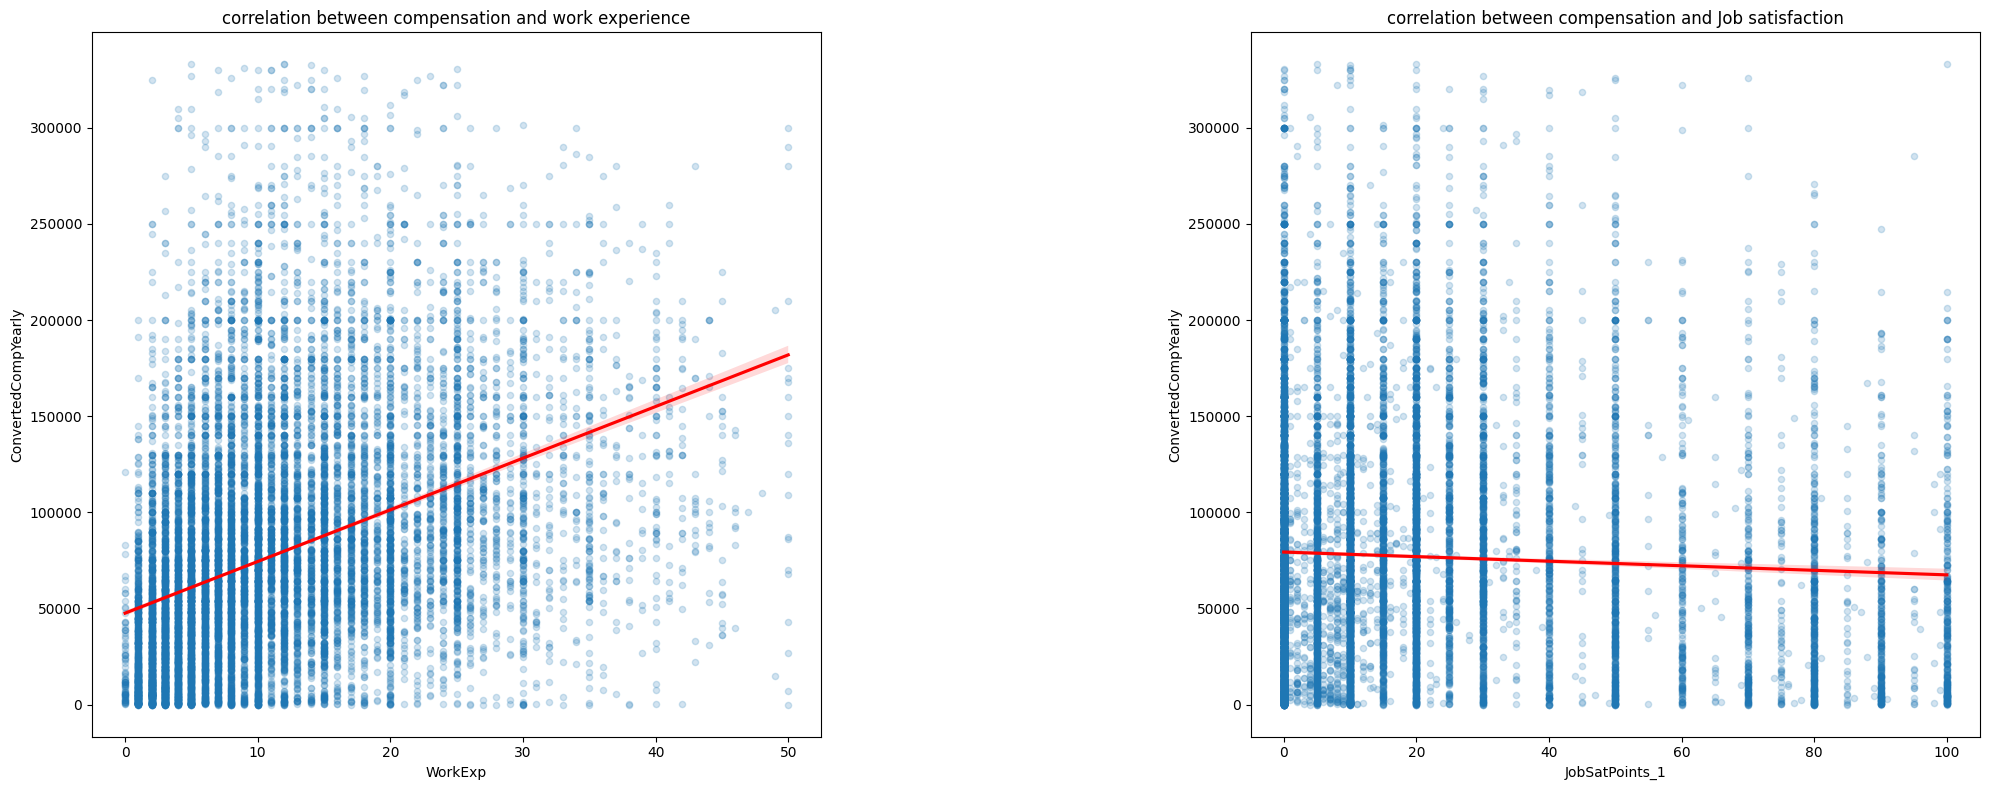

In [8]:
## Write your code here

exp_comp=df_compensation[['ConvertedCompYearly','WorkExp']]
sat_comp=df_compensation[['ConvertedCompYearly','JobSatPoints_1']]

print('experience and compensation null values before cleaning:\n',exp_comp.isnull().sum())
exp_comp=exp_comp.dropna(axis=0)
print('\n\n experience and compensation null values before cleaning:\n',exp_comp.isnull().sum())

print('\n\n\n\n job satisfaction and compensation null values before cleaning:\n',sat_comp.isnull().sum())
sat_comp=sat_comp.dropna(axis=0)
print('\n\n job satisfaction and compensation null values before cleaning:\n',sat_comp.isnull().sum())


fig=plt.figure(figsize=(20,8))
ax0=fig.add_subplot(1,2,1)
ax1=fig.add_subplot(1,2,2)

sns.regplot(exp_comp, x='WorkExp', y='ConvertedCompYearly', line_kws={'color':'red'}, ax=ax0, scatter_kws={'s':20, 'alpha':0.2})
ax0.set_title('correlation between compensation and work experience')

sns.regplot(sat_comp, x='JobSatPoints_1', y='ConvertedCompYearly', line_kws={'color':'red'}, ax=ax1, scatter_kws={'s':20, 'alpha':0.2})
ax1.set_title('correlation between compensation and Job satisfaction')

plt.tight_layout(w_pad=25)
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
